# Predicting Car Fuel Efficiency Using Multiple Linear Regression
### Auto MPG Dataset — UCI Machine Learning Repository
**Features:** Cylinders, Displacement, Horsepower, Weight, Acceleration, Model Year, Origin  
**Target:** MPG (Miles per Gallon)

## Dataset — Auto MPG

**Source:** UCI Machine Learning Repository  
**Records:** 398 cars from the 1970s and 80s  
**Goal:** Predict fuel efficiency (MPG) from car specifications

| Column | Type | Description |
|---|---|---|
| `mpg` | Target | Miles per gallon — fuel efficiency |
| `cylinders` | Feature | Number of engine cylinders |
| `displacement` | Feature | Engine displacement (cubic inches) |
| `horsepower` | Feature | Engine horsepower |
| `weight` | Feature | Vehicle weight (lbs) |
| `acceleration` | Feature | Time to accelerate 0-60 mph (seconds) |
| `model_year` | Feature | Last 2 digits of model year (e.g. 70 = 1970) |
| `origin` | Feature | 1 = USA, 2 = Europe, 3 = Japan |
| `car_name` | Info only | Name of the car (not used in model) |

In [3]:
#importing libraries

import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 
           'weight', 'acceleration', 'model_year', 'origin', 'car_name']

df = pd.read_csv(url,names = columns, sep = r'\s+')

In [5]:
#display first 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [6]:
# Check basic statistics
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
# Check shape, column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [8]:
#Checking for null data
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [9]:
df['horsepower'].unique()

array(['130.0', '165.0', '150.0', '140.0', '198.0', '220.0', '215.0',
       '225.0', '190.0', '170.0', '160.0', '95.00', '97.00', '85.00',
       '88.00', '46.00', '87.00', '90.00', '113.0', '200.0', '210.0',
       '193.0', '?', '100.0', '105.0', '175.0', '153.0', '180.0', '110.0',
       '72.00', '86.00', '70.00', '76.00', '65.00', '69.00', '60.00',
       '80.00', '54.00', '208.0', '155.0', '112.0', '92.00', '145.0',
       '137.0', '158.0', '167.0', '94.00', '107.0', '230.0', '49.00',
       '75.00', '91.00', '122.0', '67.00', '83.00', '78.00', '52.00',
       '61.00', '93.00', '148.0', '129.0', '96.00', '71.00', '98.00',
       '115.0', '53.00', '81.00', '79.00', '120.0', '152.0', '102.0',
       '108.0', '68.00', '58.00', '149.0', '89.00', '63.00', '48.00',
       '66.00', '139.0', '103.0', '125.0', '133.0', '138.0', '135.0',
       '142.0', '77.00', '62.00', '132.0', '84.00', '64.00', '74.00',
       '116.0', '82.00'], dtype=object)

we have detected '?' character in the horsepower 

In [10]:
#replace incorrect entries with 'nan'
df['horsepower'] = df['horsepower'].replace('?',np.nan)

In [11]:
df['horsepower'] = pd.to_numeric(df['horsepower'])

In [12]:
# handling mising values
# How many missing values?
print("Missing:", df['horsepower'].isnull().sum())

Missing: 6


In [13]:
print('Mean:', df['horsepower'].mean())
print('Median:',df['horsepower'].median())

Mean: 104.46938775510205
Median: 93.5


In [14]:
#filling na with Median due to the skewed value
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [15]:
print('Mean:', df['horsepower'].mean())
print('Median:',df['horsepower'].median())

Mean: 104.30402010050251
Median: 93.5


In [16]:
print(df.drop(columns = ['car_name']).corr()['mpg'])

mpg             1.000000
cylinders      -0.775396
displacement   -0.804203
horsepower     -0.773453
weight         -0.831741
acceleration    0.420289
model_year      0.579267
origin          0.563450
Name: mpg, dtype: float64


In [17]:
# Prepare data for Multiple Regression

#Our X has multiple inputs
X = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']]

#output y

y = df['mpg']


In [18]:
# Split the data into 80% training and 20% testing 
#This allows 20% of the data is unexposed to the training set so that we can apply on test data to check our prediction works fine
# random_state=42 ensures we get the same split every time we run

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [19]:
#Check the size of train and test dataset

print('Training Size:',len(X_train))
print('Test Size:',len(X_test))

Training Size: 318
Test Size: 80


In [20]:
#Loding model

model = linear_model.LinearRegression()
model.fit(X_train,y_train)

print('Model Trained')

Model Trained


In [21]:
#Slope and Intercept

print('Slope:',model.coef_)
print('Intercept:',model.intercept_)

Slope: [-0.15679336  0.01422034 -0.0131871  -0.00674638  0.06877567  0.79495958
  1.32295917]
Intercept: -20.559318508498514


In [22]:
#applying prediction on the test data

y_pred = model.predict(X_test)

In [23]:
#Loading the first 5 data from our predictions
y_pred[:5]

array([32.88140046, 29.55780381, 21.36955005, 16.79734409, 12.4982001 ])

In [24]:
# Our Actual values from the y_test

print('Actual:',list(y_test[:5]))

Actual: [33.0, 28.0, 19.0, 13.0, 14.0]


In [25]:
# calculating the mean Squared error on the test data and predicted data

mse = mean_squared_error(y_test,y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 8.197746885824984


##### MPG in our dataset ranges from 9 to 46
##### RMSE = √8.19 ≈ 2.86 MPG
##### So on average our predictions are off by ~2.86 MPG \\\

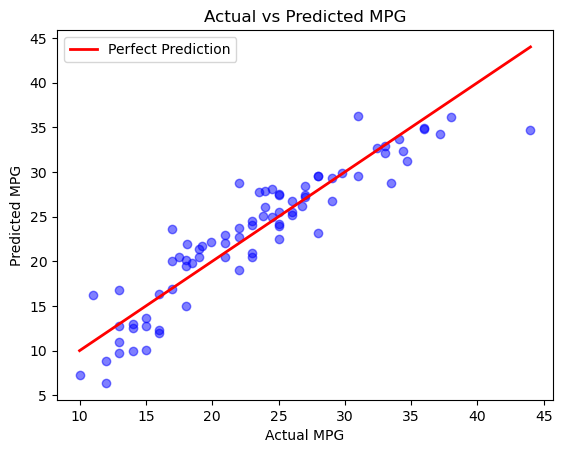

In [26]:
# Since we have done multiple regression, its not possible to visualize Miles per Gallon against each metrics
# We have drafted the graph by validating aginst the predicted and actual MPG

plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG')
plt.legend()
plt.show()

### Key Findings

- **Weight** has the strongest negative correlation (-0.83)
  → Heavier cars consume more fuel, lighter cars are more efficient

- **Displacement** has a strong negative correlation (-0.80)
  → Bigger engines consume more fuel

- **Horsepower** has a strong negative correlation (-0.77)
  → More powerful engines consume more fuel

- **Cylinders** has a strong negative correlation (-0.78)
  → More cylinders means more fuel consumption

- **Model Year** has the strongest positive correlation (+0.58)
  → Newer cars are more fuel efficient (better technology)

- **Origin** shows positive correlation (+0.56)
  → European and Japanese cars tend to be more fuel efficient than American cars

- **MSE: 8.19 → RMSE: ~2.86 MPG** on a range of 9-46 MPG
  → Predictions are off by ~2.86 MPG on average which is reasonable

- Using **7 features** gave significantly richer predictions
  than single feature regression